In [1]:
import pandas as pd

# Loading Clean Data

In [2]:
df = pd.read_csv('dataset_clean.csv')

Quick look at the first 5 rows to verify the data loaded correctly and check column names and values.

In [3]:
df.head()

,record_id,marketing_original_source,marketing_latest_source,device,country,lead_source_detail,visitor_type,destination_interest,budget_range,travel_group_type,...,sales_activity_count,qualified_flag,interaction_depth,pipeline_stage_num,total_activities,deal_progress,nurture_score,readiness_score,target_conv_prob,target_profit
0,192101810608,PAID_SOCIAL,PAID_SOCIAL,Mobile,Uzbekistan,From a friend,Unknown,KENYA,NOTSURE,FRIENDS,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003785,56853.953125
1,187910798497,AI_REFERRALS,PAID_SEARCH,Mobile,United Kingdom,Social Media,FIRST_VISITOR_NO_RESEARCH,Unknown,NOTSURE,SOLO,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025621,46032.949219
2,192101812905,PAID_SOCIAL,PAID_SOCIAL,Mobile,Philippines,Unknown,Unknown,KENYA,NOTSURE,SOLO,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022857,64591.765625
3,192100140918,PAID_SEARCH,REFERRALS,Mobile,Canada,Google or other search,FIRST_VISITOR_NO_RESEARCH,SOUTH AFRICA;KENYA,5000 - 10000 CAD,PARTNER,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.005135,50077.187500
4,192082891308,EMAIL_MARKETING,EMAIL_MARKETING,Desktop,United States,Google or other search,FIRST_VISITOR_NO_RESEARCH,SOUTH AFRICA;OPEN TO IDEAS,4000 - 7000 USD,PARTNER,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.006613,61835.500000


Statistical summary of all numeric columns — shows mean, std, min, max for each feature. Helps spot any outliers or unusual ranges.

In [4]:
df.describe()

,record_id,enquiry_touchpoints,form_submissions,page_interactions,unknown_engagement_1,total_visits,total_sessions,average_pageviews,number_of_pageviews,number_of_sessions,...,sales_activity_count,qualified_flag,interaction_depth,pipeline_stage_num,total_activities,deal_progress,nurture_score,readiness_score,target_conv_prob,target_profit
count,2.458000e+03,2458.000000,2458.000000,2458.000000,2458.000000,2458.00000,2458.000000,2458.000000,2458.000000,2458.000000,...,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000,2458.000000
mean,1.860004e+11,2.740439,0.161513,2.810415,0.161513,2.34703,1.864931,2.801465,46.938161,11.575264,...,0.299837,0.051261,0.065500,0.318959,0.303906,0.059398,0.073637,0.102929,0.051159,112377.546272
std,4.600886e+10,3.137754,0.562308,2.783583,0.562308,3.28258,0.818278,2.129231,758.975806,150.093696,...,0.623779,0.220575,0.258714,0.503119,0.574871,0.306840,0.326344,0.342938,0.080963,69478.388973
min,1.441860e+07,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001331,26513.148438
25%,1.912507e+11,2.000000,0.000000,2.000000,0.000000,2.00000,2.000000,2.000000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005244,67418.544922
50%,1.942631e+11,2.000000,0.000000,2.000000,0.000000,2.00000,2.000000,2.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.019286,91068.984375
75%,2.108085e+11,3.000000,0.000000,3.000000,0.000000,2.00000,2.000000,3.000000,11.000000,4.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.057623,136006.738281
max,2.129097e+11,73.000000,7.000000,70.000000,7.000000,87.00000,7.000000,25.000000,29995.000000,4503.000000,...,16.000000,1.000000,3.000000,5.000000,10.000000,6.000000,6.000000,6.000000,0.657205,669780.750000


Checking data types and non-null counts for every column. Confirms there are no missing values after our Phase 1 cleaning.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2458 entries, 0 to 2457
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   record_id                  2458 non-null   int64  
 1   marketing_original_source  2458 non-null   object 
 2   marketing_latest_source    2458 non-null   object 
 3   device                     2458 non-null   object 
 4   country                    2458 non-null   object 
 5   lead_source_detail         2458 non-null   object 
 6   visitor_type               2458 non-null   object 
 7   destination_interest       2458 non-null   object 
 8   budget_range               2458 non-null   object 
 9   travel_group_type          2458 non-null   object 
 10  trip_duration              2458 non-null   object 
 11  budget_level               2458 non-null   object 
 12  currency                   2458 non-null   object 
 13  age_bracket                2458 non-null   objec

# Drop Useless Columns

Dropping 8 columns based on correlation analysis:

Rule 1 — Weak correlation with both targets (< 0.05):
- destination_interest (conv=0.049, profit=0.007 — barely affects either prediction)
- qualified_flag (conv=0.009, profit=0.028 — weakest feature + 95% zeros)

Rule 2 — Duplicate features (> 0.85 correlation with each other):
- form_submissions (1.000 correlation with unknown_engagement_1 — exact copy, keeping one)
- number_of_pageviews (0.922 correlation with number_of_sessions — near duplicate, keeping the stronger one)

Rule 3 — 90%+ zeros (barely any data to learn from):
- deal_progress (94.9% zeros)
- interaction_depth (93.7% zeros)
- nurture_score (93.4% zeros)
- readiness_score (90.4% zeros)

In [8]:
drop_cols = [
    'destination_interest',               
    'qualified_flag',          
    'form_submissions',        
    'number_of_pageviews',                       
    'interaction_depth',               
    'deal_progress',          
    'nurture_score',           
    'readiness_score',         
]

df = df.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns → {df.shape[1]} remaining")

Dropped 8 columns → 29 remaining


# ENCODING CATEGORICAL COLUMNS

Using Label Encoding to convert  categorical columns (like device, budget_level, lead_type) into numbers. We chose Label Encoding over One-Hot because our main models (Random Forest, XGBoost) are tree-based and handle encoded labels well without needing separate columns for each category.

In [9]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object']).columns.tolist()


le_dict = {}  
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"  {col:30s} → {len(le.classes_)} categories encoded")

print(f"\nAll columns now numeric: {df.shape[1]} columns")

  marketing_original_source      → 11 categories encoded
  marketing_latest_source        → 11 categories encoded
  device                         → 4 categories encoded
  country                        → 132 categories encoded
  lead_source_detail             → 9 categories encoded
  visitor_type                   → 5 categories encoded
  budget_range                   → 87 categories encoded
  travel_group_type              → 5 categories encoded
  trip_duration                  → 6 categories encoded
  budget_level                   → 8 categories encoded
  currency                       → 7 categories encoded
  age_bracket                    → 4 categories encoded
  lead_type                      → 7 categories encoded
  booking_intent                 → 5 categories encoded

All columns now numeric: 29 columns


# Separate Features and Targets

record_id is just an identifier so we drop it from features. We separate the data into X (input features) and two targets: y_conv (conversion probability) and y_profit (predicted profit). The model will learn to predict these two values from the features.

In [10]:
X = df.drop(columns=['record_id', 'target_conv_prob', 'target_profit'])
y_conv = df['target_conv_prob']
y_profit = df['target_profit']

In [11]:
print(f"Features (X):      {X.shape[1]} columns")
print(f"Target 1 : {y_conv.shape[0]} values — range [{y_conv.min():.4f}, {y_conv.max():.4f}]")
print(f"Target 2 : {y_profit.shape[0]} values — range [{y_profit.min():.0f}, {y_profit.max():.0f}]")

Features (X):      26 columns
Target 1 : 2458 values — range [0.0013, 0.6572]
Target 2 : 2458 values — range [26513, 669781]


# Train/Test Split (80/20)

Splitting data into 80% training (1,966 rows) and 20% testing (492 rows). random_state=42 ensures the split is the same every time we run the code, so results are reproducible.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_conv_train, y_conv_test, y_profit_train, y_profit_test = train_test_split(
    X, y_conv, y_profit, test_size=0.2, random_state=42
)

In [14]:
print(f"\nTrain set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")


Train set: 1966 rows
Test set:  492 rows


# Train Models


3 regression models selected:
- **Linear Regression** → baseline model, simple and fast, helps us see if the data has any linear patterns
- **Random Forest** (n_estimators=100, max_depth=10) → handles non-linear relationships, works well with mixed feature types
- **XGBoost** (n_estimators=100, max_depth=6, learning_rate=0.1) → generally the best performer on tabular/structured data, handles skewed targets well

All three are regressors because both our targets are continuous values, not categories.

In [15]:
!conda install -c conda-forge xgboost -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [20]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
}

# TARGET 1: target_conv_prob

In [21]:
conv_results = {}
for name, model in models.items():
    model.fit(X_train, y_conv_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_conv_test, preds)
    rmse = np.sqrt(mean_squared_error(y_conv_test, preds))
    r2 = r2_score(y_conv_test, preds)
    conv_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"\n  {name}:")
    print(f"    MAE  = {mae:.4f}")
    print(f"    RMSE = {rmse:.4f}")
    print(f"    R²   = {r2:.4f}")


  Linear Regression:
    MAE  = 0.0386
    RMSE = 0.0652
    R²   = 0.4130

  Random Forest:
    MAE  = 0.0238
    RMSE = 0.0468
    R²   = 0.6977

  XGBoost:
    MAE  = 0.0228
    RMSE = 0.0450
    R²   = 0.7202


From the 3 models, XGBoost performed best  with R²=0.7202 for conversion probability. Random Forest came close as second best. Linear Regression performed worst, confirming that the relationship between features and targets is non-linear.

# TARGET 2: target_profit

In [23]:
profit_results = {}
for name, model in models.items():
    model.fit(X_train, y_profit_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_profit_test, preds)
    rmse = np.sqrt(mean_squared_error(y_profit_test, preds))
    r2 = r2_score(y_profit_test, preds)
    profit_results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"\n  {name}:")
    print(f"    MAE  = {mae:.0f}")
    print(f"    RMSE = {rmse:.0f}")
    print(f"    R²   = {r2:.4f}")


  Linear Regression:
    MAE  = 32300
    RMSE = 42735
    R²   = 0.5851

  Random Forest:
    MAE  = 20726
    RMSE = 32584
    R²   = 0.7588

  XGBoost:
    MAE  = 20719
    RMSE = 34697
    R²   = 0.7265


From the 3 models, **Random Forest performed best** with R²=0.7588 for profit prediction, with XGBoost close behind at R²=0.7265. Both ensemble models significantly outperformed Linear Regression, confirming that the relationship between features and targets is non-linear.

# Results Comparison

Side-by-side comparison of all 3 models on both targets. MAE = average prediction error, RMSE = penalizes big errors more, R² = how much of the target pattern the model captures (closer to 1 = better).

In [24]:
print("\n  Conversion Probability:")
print(f"  {'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print(f"  {'-'*49}")
for name, r in conv_results.items():
    print(f"  {name:<25} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f}")


  Conversion Probability:
  Model                          MAE     RMSE       R²
  -------------------------------------------------
  Linear Regression           0.0386   0.0652   0.4130
  Random Forest               0.0238   0.0468   0.6977
  XGBoost                     0.0228   0.0450   0.7202


In [25]:
print("\n  Profit Prediction:")
print(f"  {'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print(f"  {'-'*49}")
for name, r in profit_results.items():
    print(f"  {name:<25} {r['MAE']:>8.0f} {r['RMSE']:>8.0f} {r['R2']:>8.4f}")



  Profit Prediction:
  Model                          MAE     RMSE       R²
  -------------------------------------------------
  Linear Regression            32300    42735   0.5851
  Random Forest                20726    32584   0.7588
  XGBoost                      20719    34697   0.7265


# Feature Importance

Retraining XGBoost on both targets separately to extract feature importance. This tells us which features the model relies on most when making predictions — useful for understanding what drives lead conversion and profit.

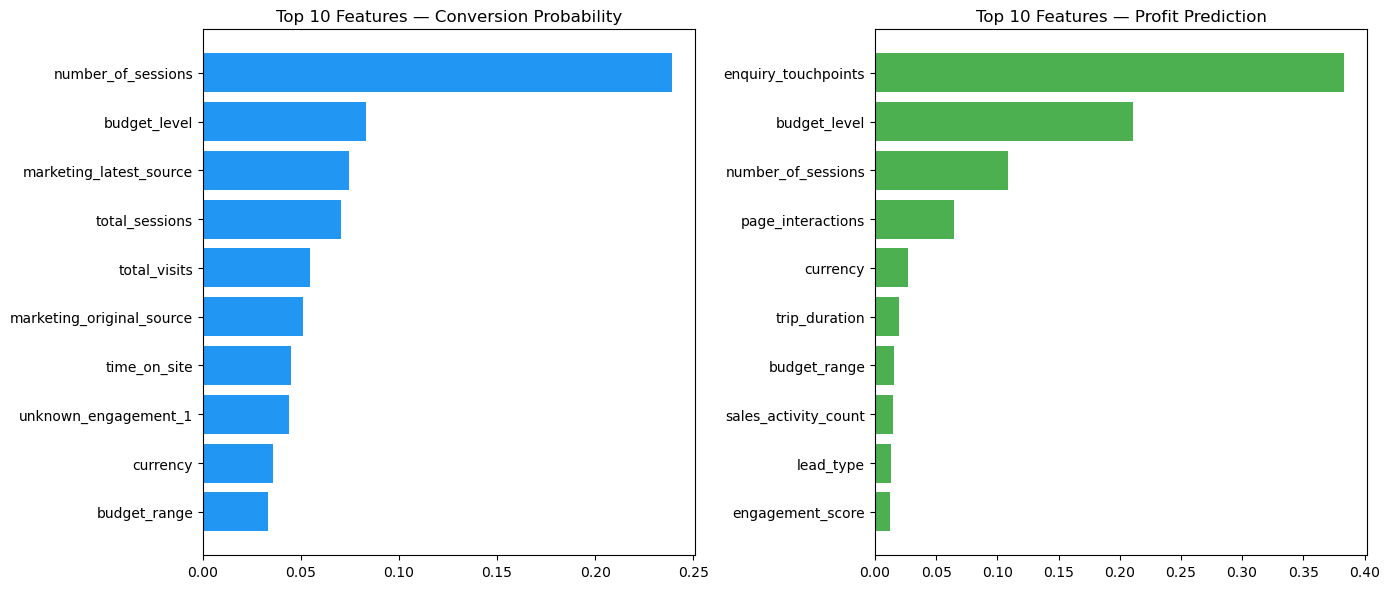

In [26]:
import matplotlib.pyplot as plt
xgb_conv = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_conv.fit(X_train, y_conv_train)

xgb_profit = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_profit.fit(X_train, y_profit_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Conv prob feature importance
feat_imp_conv = pd.Series(xgb_conv.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
axes[0].barh(feat_imp_conv.index[::-1], feat_imp_conv.values[::-1], color='#2196F3')
axes[0].set_title('Top 10 Features — Conversion Probability')


# Profit feature importance
feat_imp_profit = pd.Series(xgb_profit.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
axes[1].barh(feat_imp_profit.index[::-1], feat_imp_profit.values[::-1], color='#4CAF50')
axes[1].set_title('Top 10 Features — Profit Prediction')

plt.tight_layout()
plt.show()

# Predictions vs Actuals Plot

Scatter plot of actual vs predicted values. If the model is perfect, all points would fall exactly on the red diagonal line. Points close to the line = good predictions, points far away = big errors.

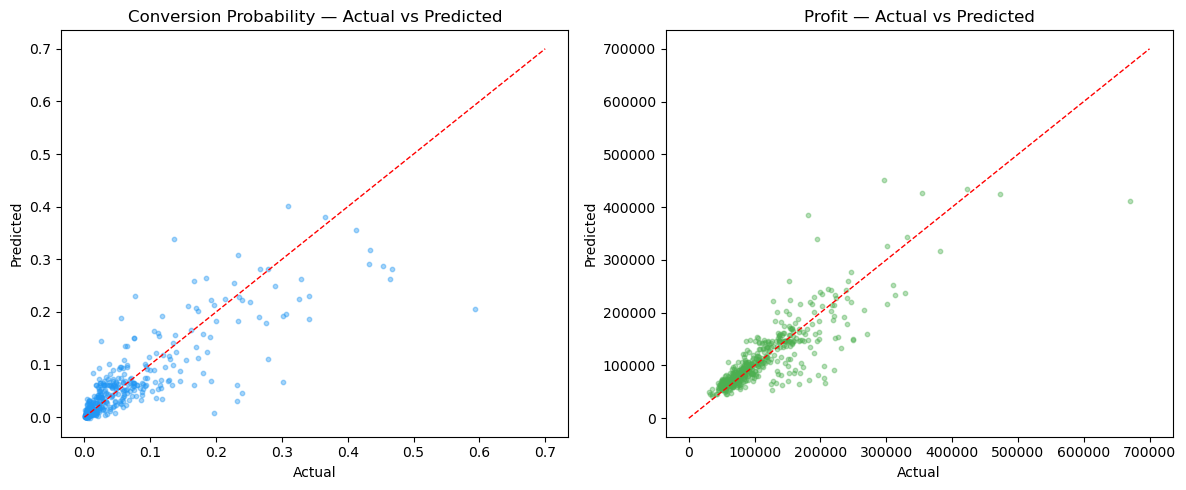

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
conv_preds = xgb_conv.predict(X_test)
axes[0].scatter(y_conv_test, conv_preds, alpha=0.4, s=10, color='#2196F3')
axes[0].plot([0, 0.7], [0, 0.7], 'r--', linewidth=1) 
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Conversion Probability — Actual vs Predicted')

profit_preds = xgb_profit.predict(X_test)
axes[1].scatter(y_profit_test, profit_preds, alpha=0.4, s=10, color='#4CAF50')
axes[1].plot([0, 700000], [0, 700000], 'r--', linewidth=1)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Profit — Actual vs Predicted')
plt.tight_layout()

# Conclusion

We trained 3 regression models (Linear Regression, Random Forest, XGBoost) to predict two targets from Go2Africa's lead data:

**Target 1 — Conversion Probability:** XGBoost performed best with R²=0.7202 and MAE=0.0228. This means the model explains about 72% of why some leads convert and others don’t, with an average error of just 2.3 percentage points.

**Target 2 — Predicted Profit:** Random Forest performed best with R²=0.7588 and MAE=20,726. The model explains about 76% of profit variation, with an average error of ~21K USD on deals ranging from 26K to 670K. XGBoost was a close second (R²=0.7265, MAE=20,719).

**Key findings:**
- Behavioral features (time_on_site, total_sessions, enquiry_touchpoints) are the strongest predictors — not profile data like budget or travel type
- XGBoost was the top performer for conversion probability prediction
- Random Forest edged ahead of XGBoost for profit prediction
- Linear Regression was the weakest model on both targets, confirming non-linear relationships in the data


